# Concept Recovery Analysis

Badamy jak agresywny debiasing na jednej warstwie jest odbudowywany przez kolejne warstwy sieci.

**Pipeline:**
1. Wyciagamy aktywacje CLS z warstwy `DEBIAS_LAYER` (surowe, bez wczesniejszego debiasingu)
2. Iteracyjnie (x`N_ITER`) wyznaczamy CAV i rzutujemy - sledzi accuracy przy kazdej iteracji
3. Wstrzykujemy N_ITER-zdebiesowane aktywacje z powrotem do CLIP na warstwie `DEBIAS_LAYER`
4. Reszta sieci dziala normalnie (zero debiasingu) - zbieramy CLS ze wszystkich kolejnych warstw
5. Na kazdej z tych warstw trenujemy LR i mierzymy accuracy - wykres powrotu konceptu

**Zmien tylko `CONCEPT`, `DEBIAS_LAYER`, `METHOD` - reszta wynika automatycznie.**

In [1]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from transformers import AutoModel, AutoImageProcessor
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
load_dotenv()

True

In [2]:
CONCEPT       = 'eyeglasses'   # zmien
DEBIAS_LAYER  = 15             # warstwa na ktorej robimy N_ITER-krotny debiasing
METHOD        = 'lr'   # 'diff_means' | 'lr' | 'pclarc'
N_ITER        = 7              # liczba iteracji CAV + rzutowania

NUM_LAYERS     = 24
GPU_BATCH_SIZE = 32
NUM_WORKERS    = 0
MODEL_ID       = 'openai/clip-vit-large-patch14'
PARQUET_COMPRESSION = 'snappy'

assert 0 <= DEBIAS_LAYER < NUM_LAYERS - 1, \
    f'DEBIAS_LAYER musi byc w [0, {NUM_LAYERS - 2}]'
assert METHOD in ('diff_means', 'lr', 'pclarc'), \
    "METHOD musi byc jednym z: 'diff_means', 'lr', 'pclarc'"

print(f'Koncept      : {CONCEPT}')
print(f'Warstwa      : {DEBIAS_LAYER}')
print(f'Metoda CAV   : {METHOD}')
print(f'Iteracje     : {N_ITER}')

Koncept      : eyeglasses
Warstwa      : 15
Metoda CAV   : lr
Iteracje     : 7


In [3]:
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / 'pyproject.toml').exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

METADATA_PATH = ROOT / 'data' / f'metadata_{CONCEPT}.csv'
IMAGES_DIR    = ROOT / 'data' / f'images_{CONCEPT}'

RUN_ID   = f'layer{DEBIAS_LAYER:02d}_{METHOD}_iter{N_ITER}'
DATA_OUT = ROOT / 'data' / 'checkpoint2_data' / CONCEPT / 'recovery' / RUN_ID
DATA_OUT.mkdir(parents=True, exist_ok=True)

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f'Brak metadanych: {METADATA_PATH}\n'
        f"Uruchom scripts/download_data.ipynb z CONCEPT='{CONCEPT}'"
    )
if not IMAGES_DIR.exists():
    raise FileNotFoundError(f'Brak folderu ze zdjeciami: {IMAGES_DIR}')

print(f'ROOT     : {ROOT}')
print(f'Data out : {DATA_OUT}')

ROOT     : e:\Do gita\WB2
Data out : e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\recovery\layer15_lr_iter7


In [4]:
df_meta = pd.read_csv(METADATA_PATH)
if CONCEPT not in df_meta.columns:
    raise ValueError(
        f"Brak kolumny '{CONCEPT}' w {METADATA_PATH}.\n"
        f'Dostepne: {list(df_meta.columns)}'
    )

df_train = df_meta[df_meta['split'] == 'train'].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'test'].reset_index(drop=True)

print(f'Train : {len(df_train)} | {df_train[CONCEPT].mean():.1%} pos')
print(f'Test  : {len(df_test)}  | {df_test[CONCEPT].mean():.1%} pos')

Train : 1792 | 50.0% pos
Test  : 256  | 50.0% pos


In [5]:
HF_TOKEN = os.getenv('HF_TOKEN')
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype    = torch.bfloat16 if device == 'cuda' else torch.float32

processor = AutoImageProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(
    MODEL_ID,
    dtype=dtype,
    low_cpu_mem_usage=True,
    token=HF_TOKEN,
).to(device).eval()

print(f'Model: {MODEL_ID} | {device} | {dtype}')


class CelebADataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.images_dir / row['filename']).convert('RGB')
        px  = self.processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        return px, int(row[CONCEPT])


def make_loader(df):
    return DataLoader(
        CelebADataset(df, IMAGES_DIR, processor),
        batch_size=GPU_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )

loader_train = make_loader(df_train)
loader_test  = make_loader(df_test)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Model: openai/clip-vit-large-patch14 | cuda | torch.bfloat16


In [6]:

def compute_diff_means(X_tr, y_tr):
    X = X_tr.astype(np.float64)
    diff = X[y_tr == 1].mean(axis=0) - X[y_tr == 0].mean(axis=0)
    n = np.linalg.norm(diff)
    return (diff / n).astype(np.float32) if n > 1e-10 else None


def compute_lr_cav(X_tr, y_tr):
    sc = StandardScaler()
    Xs = sc.fit_transform(X_tr.astype(np.float64))
    lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=2000, random_state=42)
    lr.fit(Xs, y_tr)
    # wagi z powrotem do przestrzeni oryginalnej
    w = lr.coef_[0] / sc.scale_
    n = np.linalg.norm(w)
    if n < 1e-10:
        return None, sc, lr
    return (w / n).astype(np.float32), sc, lr


def cav_accuracy_dm(X, y, cav):
    proj = X.astype(np.float64) @ cav.astype(np.float64)
    t    = (proj[y == 1].mean() + proj[y == 0].mean()) / 2
    acc  = accuracy_score(y, (proj > t).astype(int))
    return max(acc, 1.0 - acc)


def cav_accuracy_lr(X, y, sc, lr_m):
    return lr_m.score(sc.transform(X.astype(np.float64)), y)


def apply_orthogonal(X, cav):
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    return (X64 - np.outer(X64 @ c64, c64)).astype(np.float32)


def apply_pclarc(X, cav, target_val):
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    return (X64 + np.outer(target_val - X64 @ c64, c64)).astype(np.float32)

In [7]:
class _StopForward(Exception):
    pass


def extract_layer(loader, layer_idx):
    """Zwraca (X: float32, y: int) - CLS token z warstwy layer_idx."""
    _buf = []

    def _hook(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        _buf.append(hidden[:, 0, :].detach().float().cpu().numpy())
        raise _StopForward()

    handle = model.vision_model.encoder.layers[layer_idx].register_forward_hook(_hook)
    X_all, y_all = [], []
    try:
        with torch.no_grad():
            for pixels, labels in loader:
                _buf.clear()
                try:
                    model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
                except _StopForward:
                    pass
                if _buf:
                    X_all.append(_buf[0])
                y_all.extend(labels.tolist())
    finally:
        handle.remove()

    return np.concatenate(X_all, axis=0), np.array(y_all, dtype=int)


print(f'Ekstrakcja warstwy {DEBIAS_LAYER} - train...')
X_tr_raw, y_tr = extract_layer(loader_train, DEBIAS_LAYER)
print(f'Ekstrakcja warstwy {DEBIAS_LAYER} - test...')
X_te_raw, y_te = extract_layer(loader_test, DEBIAS_LAYER)

print(f'Train shape: {X_tr_raw.shape} | Test shape: {X_te_raw.shape}')

Ekstrakcja warstwy 15 - train...
Ekstrakcja warstwy 15 - test...
Train shape: (1792, 1024) | Test shape: (256, 1024)


In [8]:
# Accuracy przed jakimkolwiek debiasem (iteracja 0)
if METHOD == 'lr':
    _cav0, _sc0, _lr0 = compute_lr_cav(X_tr_raw, y_tr)
    acc0_tr = cav_accuracy_lr(X_tr_raw, y_tr, _sc0, _lr0)
    acc0_te = cav_accuracy_lr(X_te_raw, y_te, _sc0, _lr0)
else:
    _cav0 = compute_diff_means(X_tr_raw, y_tr)
    acc0_tr = cav_accuracy_dm(X_tr_raw, y_tr, _cav0)
    acc0_te = cav_accuracy_dm(X_te_raw, y_te, _cav0)

iter_records = [{'iteration': 0, 'train_acc': acc0_tr, 'test_acc': acc0_te}]
print(f'Iter 0 (przed): train={acc0_tr:.3f}  test={acc0_te:.3f}')

# Iteracyjny debiasing
X_tr_deb = X_tr_raw.copy()
X_te_deb = X_te_raw.copy()
cavs        = []
target_vals = []

for it in range(1, N_ITER + 1):
    sc_it = lr_it = None
    if METHOD == 'lr':
        cav, sc_it, lr_it = compute_lr_cav(X_tr_deb, y_tr)
    else:
        cav = compute_diff_means(X_tr_deb, y_tr)

    if cav is None:
        print(f'Iter {it}: CAV=None, przerywam')
        break

    # accuracy przed tym rzutowaniem
    if METHOD == 'lr':
        acc_tr = cav_accuracy_lr(X_tr_deb, y_tr, sc_it, lr_it)
        acc_te = cav_accuracy_lr(X_te_deb, y_te, sc_it, lr_it)
    else:
        acc_tr = cav_accuracy_dm(X_tr_deb, y_tr, cav)
        acc_te = cav_accuracy_dm(X_te_deb, y_te, cav)

    # zastosuj debiasing
    if METHOD == 'pclarc':
        t_val = float(
            (X_tr_deb.astype(np.float64)[y_tr == 0] @ cav.astype(np.float64)).mean()
        )
        X_tr_deb = apply_pclarc(X_tr_deb, cav, t_val)
        X_te_deb = apply_pclarc(X_te_deb, cav, t_val)
        target_vals.append(t_val)
    else:
        X_tr_deb = apply_orthogonal(X_tr_deb, cav)
        X_te_deb = apply_orthogonal(X_te_deb, cav)
        target_vals.append(None)

    cavs.append(cav)
    iter_records.append({'iteration': it, 'train_acc': acc_tr, 'test_acc': acc_te})
    print(f'Iter {it}/{N_ITER}: train={acc_tr:.3f}  test={acc_te:.3f}')

# accuracy na finalnie zdebiesowanych aktywacjach
if METHOD == 'lr':
    _cf, _scf, _lrf = compute_lr_cav(X_tr_deb, y_tr)
    acc_fin_tr = cav_accuracy_lr(X_tr_deb, y_tr, _scf, _lrf)
    acc_fin_te = cav_accuracy_lr(X_te_deb, y_te, _scf, _lrf)
else:
    _cf = compute_diff_means(X_tr_deb, y_tr)
    if _cf is not None:
        acc_fin_tr = cav_accuracy_dm(X_tr_deb, y_tr, _cf)
        acc_fin_te = cav_accuracy_dm(X_te_deb, y_te, _cf)
    else:
        acc_fin_tr = acc_fin_te = float('nan')

# punkt N_ITER+1 = stan po wszystkich rzutowaniach
iter_records.append({'iteration': N_ITER + 1, 'train_acc': acc_fin_tr, 'test_acc': acc_fin_te})
print(f'\nPo {N_ITER} iteracjach: train={acc_fin_tr:.3f}  test={acc_fin_te:.3f}')

df_iter = pd.DataFrame(iter_records)
df_iter.to_csv(DATA_OUT / 'iter_debiasing_accuracy.csv', index=False)
print(f'Zapisano: {DATA_OUT / "iter_debiasing_accuracy.csv"}')

Iter 0 (przed): train=1.000  test=0.906
Iter 1/7: train=1.000  test=0.906
Iter 2/7: train=0.969  test=0.750
Iter 3/7: train=0.942  test=0.793
Iter 4/7: train=0.922  test=0.828
Iter 5/7: train=0.905  test=0.816
Iter 6/7: train=0.881  test=0.801
Iter 7/7: train=0.867  test=0.781

Po 7 iteracjach: train=0.847  test=0.781
Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\recovery\layer15_lr_iter7\iter_debiasing_accuracy.csv


In [9]:
RECOVERY_LAYERS = list(range(DEBIAS_LAYER + 1, NUM_LAYERS))


def run_with_injection(loader, inject_layer, debiased_cls):
    """
    Forward pass przez CLIP:
    - Na inject_layer zastepuje CLS token zdebiesowanymi aktywacjami
    - Zbiera CLS ze wszystkich warstw inject_layer+1 .. NUM_LAYERS-1
    Zwraca: dict {layer_idx -> np.ndarray (N, D)}
    """
    encoder_layers = model.vision_model.encoder.layers
    captures = {k: [] for k in RECOVERY_LAYERS}
    ptr = [0]  # mutowalny wskaznik - pozycja w debiased_cls

    def inject_hook(module, input, output):
        is_tuple = isinstance(output, tuple)
        hidden   = output[0] if is_tuple else output
        B        = hidden.shape[0]
        cls_deb  = torch.from_numpy(
            debiased_cls[ptr[0]:ptr[0] + B]
        ).to(hidden.device, dtype=hidden.dtype)
        ptr[0] += B
        h_new = hidden.clone()
        h_new[:, 0, :] = cls_deb
        return (h_new,) + output[1:] if is_tuple else h_new

    def make_cap(k):
        def hook(module, input, output):
            hidden = output[0] if isinstance(output, tuple) else output
            captures[k].append(hidden[:, 0, :].detach().float().cpu().numpy())
        return hook

    handles = [encoder_layers[inject_layer].register_forward_hook(inject_hook)]
    for k in RECOVERY_LAYERS:
        handles.append(encoder_layers[k].register_forward_hook(make_cap(k)))

    try:
        with torch.no_grad():
            for pixels, _ in loader:
                model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
    finally:
        for h in handles:
            h.remove()

    return {k: np.concatenate(v, axis=0) for k, v in captures.items()}


print('Forward pass z wstrzykieciem - train...')
caps_tr = run_with_injection(loader_train, DEBIAS_LAYER, X_tr_deb)
print('Forward pass z wstrzykieciem - test...')
caps_te = run_with_injection(loader_test, DEBIAS_LAYER, X_te_deb)
print(f'Zebrano aktywacje z warstw: {RECOVERY_LAYERS}')

Forward pass z wstrzykieciem - train...
Forward pass z wstrzykieciem - test...
Zebrano aktywacje z warstw: [16, 17, 18, 19, 20, 21, 22, 23]


In [10]:
recovery_records = []
baseline_te = iter_records[0]['test_acc']

for k in tqdm(RECOVERY_LAYERS, desc='Recovery layers'):
    X_tr_k = caps_tr[k]
    X_te_k = caps_te[k]

    sc = StandardScaler()
    Xs_tr = sc.fit_transform(X_tr_k.astype(np.float64))
    Xs_te = sc.transform(X_te_k.astype(np.float64))

    lr = LogisticRegression(C=0.01, solver='lbfgs', max_iter=2000, random_state=42)
    lr.fit(Xs_tr, y_tr)

    recovery_records.append({
        'layer_id':  k,
        'train_acc': lr.score(Xs_tr, y_tr),
        'test_acc':  lr.score(Xs_te, y_te),
    })

df_recovery = pd.DataFrame(recovery_records)
df_recovery.to_csv(DATA_OUT / 'layer_recovery_accuracy.csv', index=False)
print(f'Zapisano: {DATA_OUT / "layer_recovery_accuracy.csv"}')
df_recovery

Recovery layers:   0%|          | 0/8 [00:00<?, ?it/s]

Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\recovery\layer15_lr_iter7\layer_recovery_accuracy.csv


,layer_id,train_acc,test_acc
0,16,0.943638,0.867188
1,17,0.985491,0.894531
2,18,0.988839,0.906250
3,19,0.996652,0.945312
4,20,0.996094,0.968750
5,21,0.998326,0.964844
6,22,0.997210,0.921875
7,23,0.997768,0.949219


## Wykresy

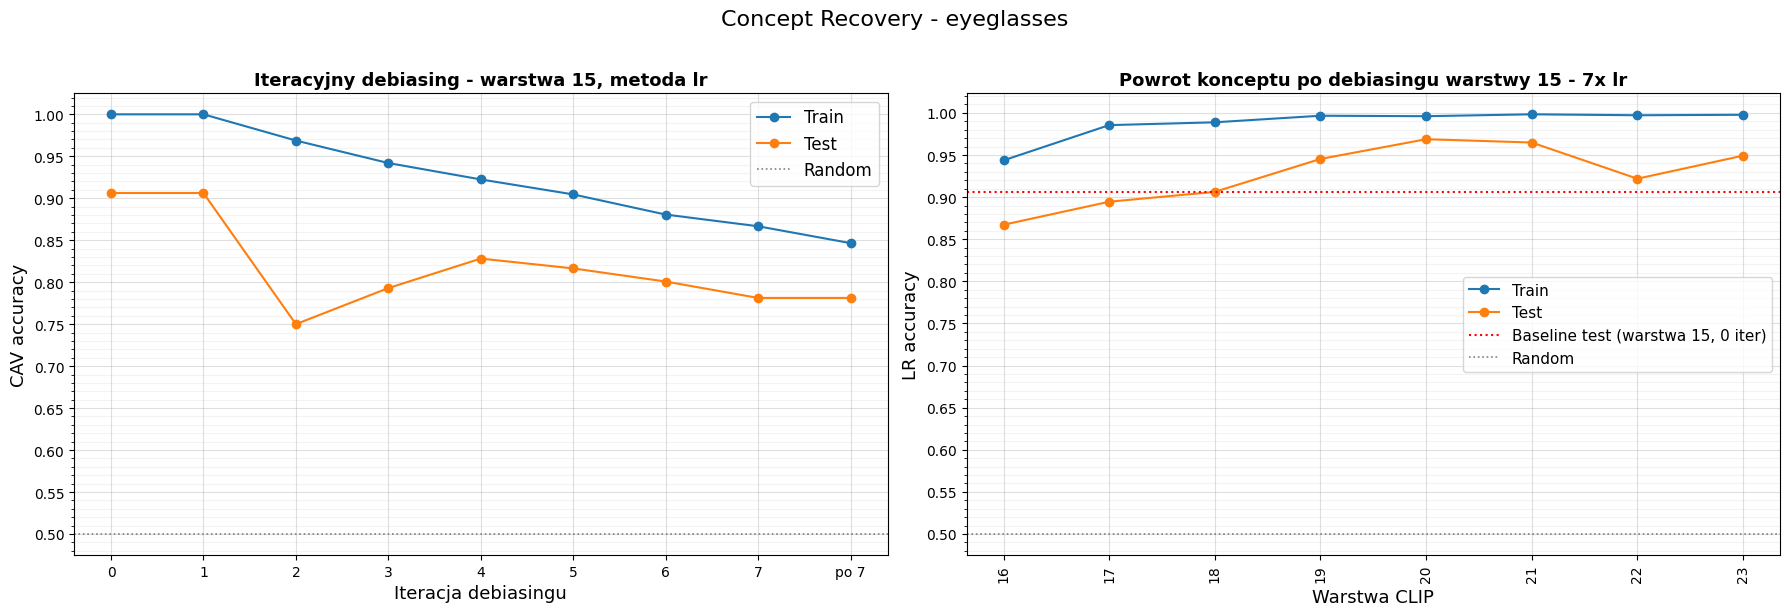

Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\recovery\layer15_lr_iter7\concept_recovery.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# lewy: accuracy przy kazdej iteracji debiasingu
ax = axes[0]
df_ip = pd.DataFrame(iter_records)
ax.plot(df_ip['iteration'], df_ip['train_acc'],
        marker='o', color='#1f77b4', ls='-', label='Train')
ax.plot(df_ip['iteration'], df_ip['test_acc'],
        marker='o', color='#ff7f0e', ls='-', label='Test')
ax.axhline(0.5, color='gray', ls=':', lw=1.2, label='Random')
ax.set_xlabel('Iteracja debiasingu', fontsize=13)
ax.set_ylabel('CAV accuracy', fontsize=13)
ax.set_title(
    f'Iteracyjny debiasing - warstwa {DEBIAS_LAYER}, metoda {METHOD}',
    fontsize=13, fontweight='bold'
)
xlabels = [str(i) if i <= N_ITER else f'po {N_ITER}' for i in df_ip['iteration']]
ax.set_xticks(df_ip['iteration'])
ax.set_xticklabels(xlabels)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(fontsize=12)

# prawy: powrot konceptu w kolejnych warstwach
ax = axes[1]
ax.plot(df_recovery['layer_id'], df_recovery['train_acc'],
        marker='o', color='#1f77b4', ls='-', label='Train')
ax.plot(df_recovery['layer_id'], df_recovery['test_acc'],
        marker='o', color='#ff7f0e', ls='-', label='Test')
ax.axhline(baseline_te, color='red', ls=':', lw=1.5,
           label=f'Baseline test (warstwa {DEBIAS_LAYER}, 0 iter)')
ax.axhline(0.5, color='gray', ls=':', lw=1.2, label='Random')
ax.set_xlabel('Warstwa CLIP', fontsize=13)
ax.set_ylabel('LR accuracy', fontsize=13)
ax.set_title(
    f'Powrot konceptu po debiasingu warstwy {DEBIAS_LAYER} - {N_ITER}x {METHOD}',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(RECOVERY_LAYERS)
ax.set_xticklabels([str(k) for k in RECOVERY_LAYERS], rotation=90)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(fontsize=11)

plt.suptitle(f'Concept Recovery - {CONCEPT}', fontsize=16, y=1.02)
plt.tight_layout()

plot_path = DATA_OUT / 'concept_recovery.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Zapisano: {plot_path}')

In [12]:
after_te      = df_ip[df_ip['iteration'] == N_ITER + 1]['test_acc'].values[0]
max_rec       = df_recovery['test_acc'].max()
max_rec_layer = int(df_recovery.loc[df_recovery['test_acc'].idxmax(), 'layer_id'])

print('=' * 55)
print(f'Koncept        : {CONCEPT}')
print(f'Warstwa debias : {DEBIAS_LAYER}  |  Metoda: {METHOD}  |  Iter: {N_ITER}')
print('-' * 55)
print(f'Accuracy przed debiasem (test)   : {baseline_te:.3f}')
print(f'Accuracy po {N_ITER} iter. (test)     : {after_te:.3f}')
print(f'Max recovery accuracy (test)     : {max_rec:.3f}  (warstwa {max_rec_layer})')
print('=' * 55)

Koncept        : eyeglasses
Warstwa debias : 15  |  Metoda: lr  |  Iter: 7
-------------------------------------------------------
Accuracy przed debiasem (test)   : 0.906
Accuracy po 7 iter. (test)     : 0.781
Max recovery accuracy (test)     : 0.969  (warstwa 20)
